A/B-тестирование — это метод сравнения двух версий продукта или решения.

Цель:

- определить, какая версия работает лучше

Принцип:

- пользователи делятся на две группы

Группа A — контрольная версия

Группа B — новая версия

Сравниваются метрики:

- конверсия

- средний чек

- CTR

- retention

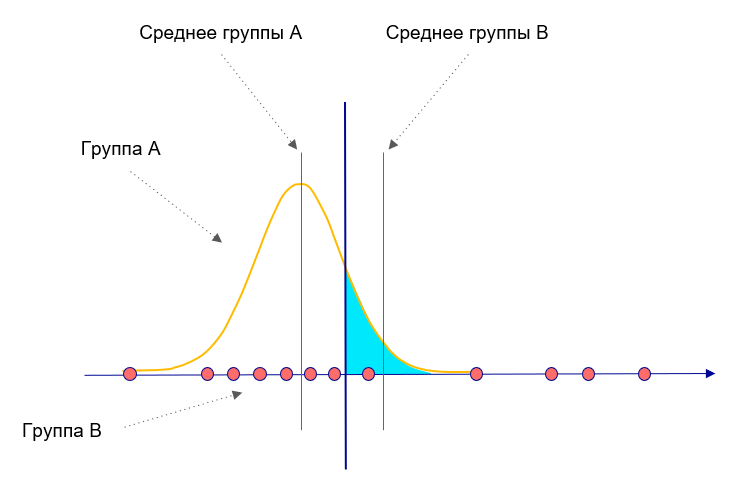

Bootstrap — метод повторной выборки.

Идея:

- случайно выбирать элементы с возвращением

- много раз пересчитывать статистику

Процесс:

1) Из исходной выборки делаем новую выборку того же размера

2) Считаем метрику

3) Повторяем 1000–10000 раз

4) Получаем распределение статистики

Преимущества:

- не требует предположений о распределении

- работает для сложных метрик.

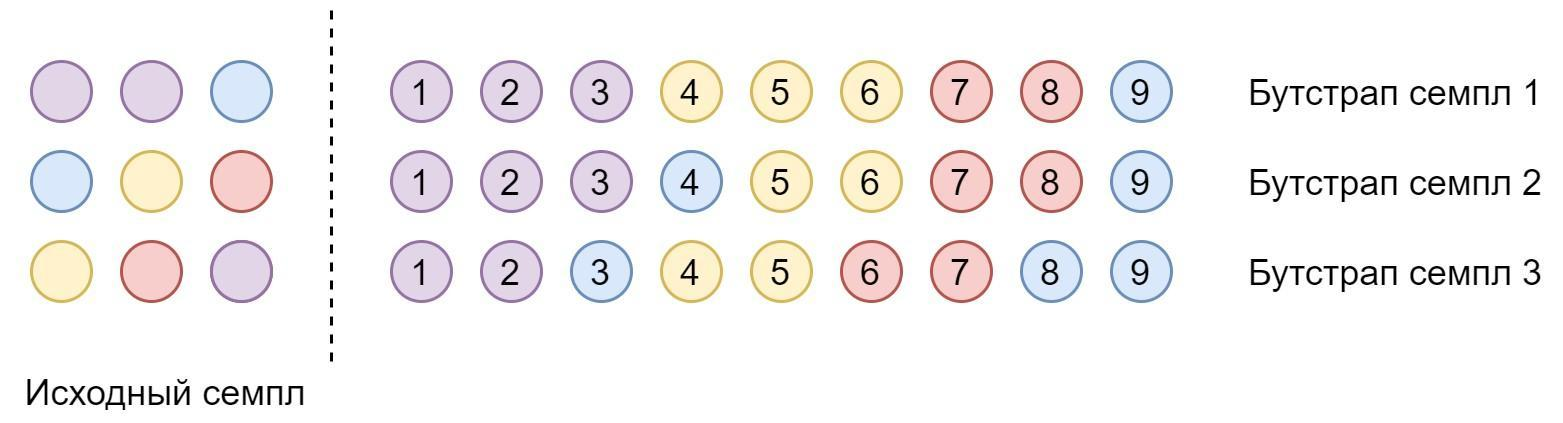

Доверительный интервал (Confidence Interval, CI) — это диапазон значений, в котором с высокой вероятностью находится истинное значение параметра.

В A/B-тестировании чаще всего это:

- средняя метрика
- конверсия
- разница между группами

Пример: Средний чек по выборке = 100€

95% доверительный интервал:

[96 ; 104]

Это означает:

Если повторять эксперимент много раз, 95% таких интервалов будут содержать истинное значение среднего.


$CI_{1-\frac{\alpha}{2}}=\overline x \pm z_{1-\frac{\alpha}{2}} \frac{s}{\sqrt{n}}$

Квантиль нормального распределения.

Он задаёт уровень доверия.

Уровень доверия	

z

90%	1.645

95%	1.96

99%	2.576

Самый популярный:

$𝑧_{0.975}=1.96$

Если мы знаем истинную дисперсию σ, можно использовать z-интервал.

Но в реальности:

σ неизвестна

её заменяют выборочной оценкой 
s

Из-за этого появляется дополнительная неопределённость, и распределение статистики становится t-распределением.

Поэтому доверительный интервал для среднего:

$$CI = \bar{x} \pm t_{1-\frac{a}{2},df}*SE$$

$$SE=\sqrt{\frac{s^2_A}{n_A}}$$

t-интервал для A/B теста

В A/B-тесте чаще интересует разница средних.

Пусть есть две группы:

A — контроль
B — эксперимент

Метрика: например

- средний чек

- время на сайте

- revenue per user

Формула для разницы

$$(\bar{x_B}- \bar{x_A}) \pm t_{1-\frac{\alpha}{2}}*SE_{diff}$$
, где 
$$SE_{diff}=\sqrt{\frac{s^2_A}{n_A}+\frac{s_B^2}{n_B}}$$

In [10]:
import numpy as np
from scipy import stats

# данные двух групп
A = np.array([10, 12, 9, 11, 10, 13, 12, 11])
B = np.array([14, 15, 13, 16, 15, 14, 17, 16])

print('Среднее A: ', A.mean())
print('Среднее B: ', B.mean())

# t-тест
t_stat, p_value = stats.ttest_ind(B, A, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Разница статистически значима")
else:
    print("Разница не значима")

Среднее A:  11.0
Среднее B:  15.0
t-statistic: 6.110100926607787
p-value: 2.695721855696088e-05
Разница статистически значима


In [5]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# число конверсий
conversions = np.array([200, 240])

# размер выборки
visitors = np.array([5000, 5100])

# z-тест
z_stat, p_value = proportions_ztest(conversions, visitors)

print("z-statistic:", z_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Разница статистически значима")
else:
    print("Разница не значима")

z-statistic: -1.7375935681217891
p-value: 0.08228245396071165
Разница не значима


In [8]:
from scipy.stats import norm

alpha = 0.05
z = abs(norm.ppf(1 - alpha / 2))
mean = np.mean(A)
std = np.std(A)
MOE = z * std / np.sqrt(2000)
ci_left, ci_right = mean - MOE, mean + MOE
print(ci_left, ci_right)

10.946324175688485 11.053675824311515


In [9]:
from scipy.stats import norm

alpha = 0.05
z = abs(norm.ppf(1 - alpha / 2))
mean = np.mean(B)
std = np.std(B)
MOE = z * std / np.sqrt(2000)
ci_left, ci_right = mean - MOE, mean + MOE
print(ci_left, ci_right)

14.946324175688485 15.053675824311515
